# RQ22 — W3 Physical Unlock Detector

**Research question:** Under the controlled W3 protocol, can the physical unlock/release event be separated from ordinary pre-unlock digit movements, and how should detector triggers be interpreted operationally?

This RQ is deliberately separate from True-Gate ranking and Binding. It evaluates the frozen **Physical Unlock Detector v1** as a lightweight physical stop/confirmation cue.

Two evidence layers are kept separate:

1. **Controlled acoustic validation:** dedicated `unlock` dataset, password 6800, 16 independently reseated CCW scans × 10 movements.
2. **Operational evidence:** archived `recognition_results/AUTO_####_##` logs, used only to count detector triggers that were operator-confirmed or operator-rejected.

The frozen detector rule is **not retuned** here:

- RMS > 0.09
- derivative RMS > 0.03

Both features use the contact microphone in a fixed `SCAN_END −30 ms → +120 ms` window.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import importlib
import sys
import pandas as pd

MYDRIVE = Path('/content/drive/MyDrive')

repro_candidates = [
    MYDRIVE / 'Padlock_Reproduction_v1' / 'Padlock_Reproduction_v1',
    MYDRIVE / 'Padlock_Reproduction_v1',
]
REPRO_ROOT = next((p for p in repro_candidates if (p / 'results').exists()), None)
if REPRO_ROOT is None:
    raise FileNotFoundError('Could not locate Padlock_Reproduction_v1.')

RESULT_DIR = REPRO_ROOT / 'results' / '22_RQ22_W3_Physical_Unlock_Detector'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR = Path('/content/rq22_work')
WORK_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(RESULT_DIR))
import RQ22_unlock_detector as rq22
rq22 = importlib.reload(rq22)

print('Reproduction root:', REPRO_ROOT)
print('Result folder:', RESULT_DIR)

Mounted at /content/drive
Reproduction root: /content/drive/MyDrive/Padlock_Reproduction_v1
Result folder: /content/drive/MyDrive/Padlock_Reproduction_v1/results/22_RQ22_W3_Physical_Unlock_Detector


## Source-data check

The controlled dataset must resolve to the actual `dataset/raw/unlock.zip` archive. The optional operational evidence is read from the actual `dataset/recognition_results` folder.

In [2]:
unlock_zip = rq22.locate_unlock_zip(MYDRIVE)
recognition_root = rq22.locate_recognition_results(MYDRIVE)

print('unlock.zip:', unlock_zip)
print('Archive size: %.1f MB' % (unlock_zip.stat().st_size / 1e6))
print('recognition_results:', recognition_root)

assert unlock_zip.stat().st_size > 10_000_000
print('RQ22 source-data check passed.')

unlock.zip: /content/drive/MyDrive/dataset/raw/unlock.zip
Archive size: 35.5 MB
recognition_results: /content/drive/MyDrive/dataset/recognition_results
RQ22 source-data check passed.


## Controlled W3 unlock validation

The first run copies the 35 MB archive to local Colab storage and extracts it locally. The persistent feature cache is then written to the RQ22 result folder, so later runs do not re-read the WAV files.

For each run, RMS and derivative RMS are recomputed directly from `audio.wav` using the event-aligned SCAN_END window. Movement 10 is excluded because it occurs after the shackle has already opened.

In [3]:
rq22 = importlib.reload(rq22)

features = rq22.prepare_unlock_feature_cache(
    mydrive=MYDRIVE,
    result_dir=RESULT_DIR,
    work_dir=WORK_DIR,
    force=False,
)

controlled, class_summary, scan_results, metrics = rq22.controlled_validation(
    features,
    RESULT_DIR,
)

print('Feature cache shape:', features.shape)
display(class_summary[['class', 'n', 'rms_min', 'rms_max', 'drms_min', 'drms_max', 'accuracy']].style.format({
    'rms_min': '{:.4f}',
    'rms_max': '{:.4f}',
    'drms_min': '{:.4f}',
    'drms_max': '{:.4f}',
    'accuracy': '{:.1%}',
}))
display(metrics.style.format({
    'movement_accuracy': '{:.1%}',
    'scan_success_rate': '{:.1%}',
    'normal_rms_max': '{:.4f}',
    'unlock_rms_min': '{:.4f}',
    'rms_gap': '{:.4f}',
    'normal_drms_max': '{:.4f}',
    'unlock_drms_min': '{:.4f}',
    'drms_gap': '{:.4f}',
}))

assert len(features) == 160
assert len(controlled) == 144
assert scan_results['scan_success'].sum() == 16
print('Controlled unlock-detector validation passed.')

Copying unlock.zip to local Colab storage (35.5 MB)
Extracting unlock.zip locally
  20/160 runs
  40/160 runs
  60/160 runs
  80/160 runs
  100/160 runs
  120/160 runs
  140/160 runs
  160/160 runs
Saved persistent feature cache: /content/drive/MyDrive/Padlock_Reproduction_v1/results/22_RQ22_W3_Physical_Unlock_Detector/RQ22_Unlock_Features.csv
Feature cache shape: (160, 12)


,class,n,rms_min,rms_max,drms_min,drms_max,accuracy
0,Normal pre-unlock,128,0.0030,0.0451,0.0002,0.0103,100.0%
1,Physical unlock,16,0.1387,0.1614,0.0580,0.0684,100.0%


,n_scans,n_valid_movements,n_normal,n_unlock,tn,fp,fn,tp,movement_accuracy,scan_success_rate,normal_rms_max,unlock_rms_min,rms_gap,normal_drms_max,unlock_drms_min,drms_gap,rms_threshold,drms_threshold
0,16,144,128,16,128,0,0,16,100.0%,100.0%,0.0451,0.1387,0.0936,0.0103,0.0580,0.0477,0.090000,0.030000


Controlled unlock-detector validation passed.


## Operational trigger audit

This section does **not** estimate sensitivity. It parses archived closed-loop recognition logs and records each Physical Unlock Detector v1 trigger together with the subsequent operator decision.

A trigger may be:

- **confirmed** — the operator physically confirmed opening;
- **rejected** — the operator rejected a release-like trigger and the W3 sweep continued;
- **unresolved** — no subsequent operator outcome is present in the log.

This distinction is important because a strong release-like transient is not automatically equivalent to physical opening.

In [4]:
triggers, operational_summary = rq22.parse_operational_logs(
    recognition_root,
    RESULT_DIR,
)

display(operational_summary.style.format({
    'confirmation_rate': '{:.1%}',
    'confirmed_true_w3_match_rate': '{:.1%}',
}))

if len(triggers):
    display(triggers[['session', 'true_combination', 'true_w3', 'trigger_w3', 'rms', 'drms', 'outcome', 'confirmed_combination', 'trigger_matches_true_w3']].style.format({
        'rms': '{:.4f}',
        'drms': '{:.4f}',
    }))
else:
    print('No named-password AUTO logs found; controlled validation remains available.')

,sessions_scanned,triggers,confirmed,rejected,unresolved,confirmation_rate,confirmed_true_w3_match_rate
0,6,7,6,1,0,85.7%,100.0%


,session,true_combination,true_w3,trigger_w3,rms,drms,outcome,confirmed_combination,trigger_matches_true_w3
0,AUTO_2475_01,2475,7,7,0.1389,0.0577,confirmed,2475,True
1,AUTO_3159_01,3159,5,5,0.1382,0.0567,confirmed,3159,True
2,AUTO_5318_01,5318,1,2,0.1600,0.0568,rejected,,False
3,AUTO_5318_01,5318,1,1,0.1511,0.0632,confirmed,5318,True
4,AUTO_6924_01,6924,2,2,0.1394,0.0556,confirmed,6924,True
5,AUTO_7642_01,7642,4,4,0.1393,0.0589,confirmed,7642,True
6,AUTO_9086_01,9086,8,8,0.1313,0.0542,confirmed,9086,True


## Final figures and report

The dissertation figures are deliberately simple. They show the largest ordinary pre-unlock event, the frozen threshold, and the smallest physical unlock event for RMS and derivative RMS.

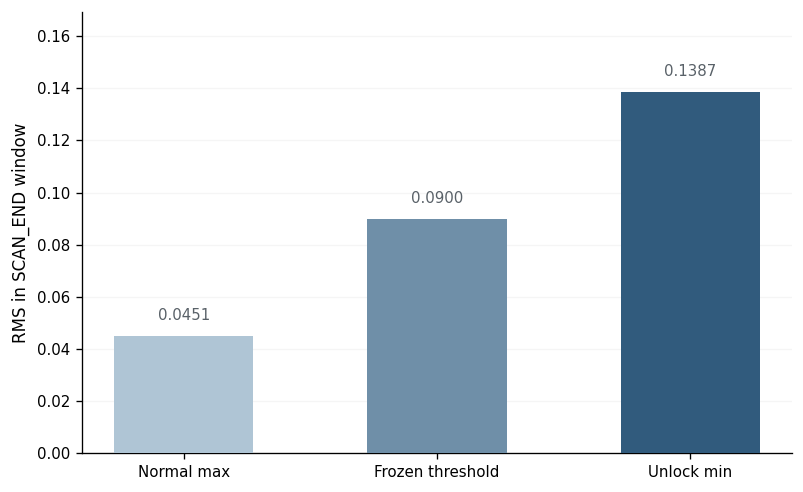

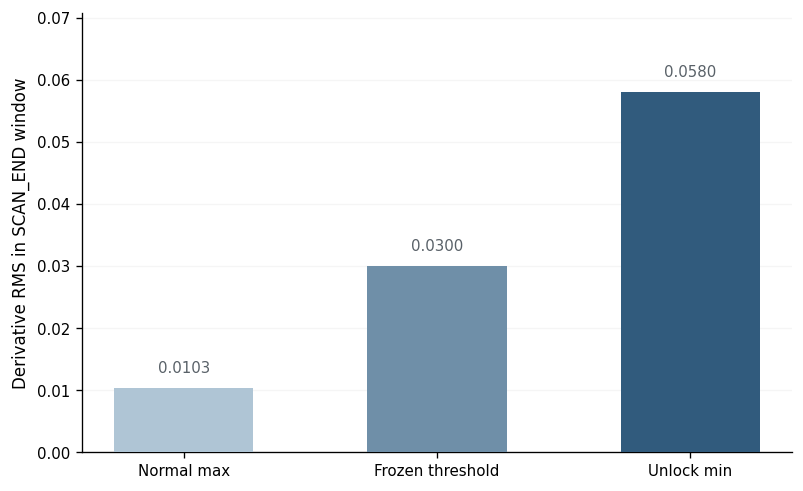

Saved:
  /content/drive/MyDrive/Padlock_Reproduction_v1/results/22_RQ22_W3_Physical_Unlock_Detector/RQ22_Fig1_RMS_Separation.png
  /content/drive/MyDrive/Padlock_Reproduction_v1/results/22_RQ22_W3_Physical_Unlock_Detector/RQ22_Fig2_dRMS_Separation.png
  /content/drive/MyDrive/Padlock_Reproduction_v1/results/22_RQ22_W3_Physical_Unlock_Detector/RQ22_Report.md
  /content/drive/MyDrive/Padlock_Reproduction_v1/results/22_RQ22_W3_Physical_Unlock_Detector/RQ22_conclusion.json

RQ22 complete.


In [5]:
rq22.save_figures(metrics, RESULT_DIR)
rq22.write_report(metrics, class_summary, operational_summary, RESULT_DIR)

print('Saved:')
for name in [
    'RQ22_Fig1_RMS_Separation.png',
    'RQ22_Fig2_dRMS_Separation.png',
    'RQ22_Report.md',
    'RQ22_conclusion.json',
]:
    print(' ', RESULT_DIR / name)

print()
print('RQ22 complete.')
